# Train the skin-lesion classifier (3 classes)

Run this on the PC with the RTX 4060 (WSL, `venv` kernel). It produces the four files the kiosk reads:

| file | what |
|---|---|
| `models/skin_classifier.tflite` | the model |
| `models/labels.txt` | `benign`, `pre_cancerous`, `malignant` |
| `models/thresholds.json` | the screening threshold (90% cancer sensitivity on validation) |
| `models/temperature.json` | T for honest displayed confidence |

Two things this notebook does that the first version did not:

1. **Splits by lesion, not by image.** HAM10000 has several photos of the same lesion. Splitting
   by image put the same lesion in train and test (40% of test images), which inflates every number.
   `GroupShuffleSplit` on `lesion_id` fixes that. `training/splits.csv` records the split.
2. **Camera-style augmentation.** The kiosk is a bare camera module, and the students demo by
   pointing it at a phone screen. `camera_augment` adds blur, JPEG re-compression, colour cast,
   exposure drift, glare, and a faint screen grid so the model has seen that kind of photo.

After it runs: `python training/eval.py` on the same machine, then copy the four files into
`models/` on the branch and commit. Nothing else needs to change.


In [1]:
# Cell 0 — WSL GPU + all imports (do not split TensorFlow into another cell).
# TF loads CUDA on first import; if it imported earlier without LD_LIBRARY_PATH, GPU stays [] until Kernel Restart.
import os
import sys
from pathlib import Path


def _detect_venv() -> str:
    v = os.environ.get("VIRTUAL_ENV")
    if v:
        return v
    exe = Path(sys.executable).resolve()
    if exe.parent.name == "bin" and (exe.parent.parent / "pyvenv.cfg").is_file():
        return str(exe.parent.parent)
    raise RuntimeError(
        "Select kernel: skin-cancer-project/venv/bin/python (venv). "
        "VIRTUAL_ENV unset and interpreter is not inside a venv."
    )


venv = _detect_venv()
_pyv = f"{sys.version_info.major}.{sys.version_info.minor}"
_base = f"{venv}/lib/python{_pyv}/site-packages/nvidia"
_cuda_libs = [
    "/usr/lib/wsl/lib",
    f"{_base}/cuda_runtime/lib",
    f"{_base}/cuda_nvrtc/lib",
    f"{_base}/cublas/lib",
    f"{_base}/cudnn/lib",
    f"{_base}/cufft/lib",
    f"{_base}/curand/lib",
    f"{_base}/cusolver/lib",
    f"{_base}/cusparse/lib",
    f"{_base}/nccl/lib",
    f"{_base}/nvjitlink/lib",
]
_prev = os.environ.get("LD_LIBRARY_PATH", "")
os.environ["LD_LIBRARY_PATH"] = ":".join([p for p in _cuda_libs + ([_prev] if _prev else []) if p])

missing = [p for p in _cuda_libs if not Path(p).is_dir()]
if missing:
    print("WARNING: missing NVIDIA wheel dirs:", missing)

print("venv:", venv)
print("Python:", sys.version.split()[0])
print("LD_LIBRARY_PATH prefix:", os.environ["LD_LIBRARY_PATH"][:140] + "...")

# Help the dynamic linker load CUDA deps before TensorFlow's GPU plugin dlopens them
# (needed on some WSL + Jupyter kernels even when LD_LIBRARY_PATH is set).
import ctypes

_preloads = [
    Path(_base) / "cuda_runtime" / "lib" / "libcudart.so.12",
    Path(_base) / "cudnn" / "lib" / "libcudnn.so.9",
    Path(_base) / "cublas" / "lib" / "libcublas.so.12",
    Path(_base) / "cublas" / "lib" / "libcublasLt.so.12",
    Path(_base) / "cusolver" / "lib" / "libcusolver.so.11",
    Path(_base) / "cusparse" / "lib" / "libcusparse.so.12",
]
for _so in _preloads:
    if _so.is_file():
        try:
            ctypes.CDLL(str(_so), mode=ctypes.RTLD_GLOBAL)
            print("Preloaded:", _so.name)
        except OSError as _e:
            print("Preload skipped/failed:", _so, _e)

# Import TensorFlow in THIS cell immediately after LD_LIBRARY_PATH + preload (required on WSL).
import tensorflow as tf

gpus = tf.config.list_physical_devices("GPU")
for g in gpus:
    tf.config.experimental.set_memory_growth(g, True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

print("TensorFlow:", tf.__version__)
print("GPU devices:", gpus)

venv: /home/hansdaduya/projects/skin-cancer-project/venv
Python: 3.12.3
LD_LIBRARY_PATH prefix: /usr/lib/wsl/lib:/home/hansdaduya/projects/skin-cancer-project/venv/lib/python3.12/site-packages/nvidia/cuda_runtime/lib:/home/hansdaduya/pr...
Preloaded: libcudart.so.12
Preloaded: libcudnn.so.9
Preloaded: libcublas.so.12
Preloaded: libcublasLt.so.12
Preloaded: libcusolver.so.11
Preloaded: libcusparse.so.12


I0000 00:00:1781031498.017945    6953 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow: 2.21.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# Cell 1 — Reproducibility + extra imports for the sensitivity-first pipeline.
# (Kept separate from the CUDA/TF import cell above on purpose.)
import json
import math
import random

import keras
from sklearn.metrics import (
    f1_score,
    recall_score,
    precision_score,
    roc_auc_score,
    average_precision_score,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.keras.utils.set_random_seed(SEED)

# Class index constants (kept in sync with LABELS defined in the class-collapse cell).
BENIGN_IDX, PRECANCER_IDX, MALIGNANT_IDX = 0, 1, 2

print("Seeds set to", SEED, "| keras", keras.__version__)


Seeds set to 42 | keras 3.14.0


In [ ]:
# Cell 2: Paths + load metadata
# HAM10000_DIR can override the default; the dataset is not in git.
DATA_DIR = os.environ.get("HAM10000_DIR", "/home/hansdaduya/projects/skin-cancer-project/datasets/ham10000")
METADATA = os.path.join(DATA_DIR, "HAM10000_metadata.csv")
PROJECT = Path.cwd() if (Path.cwd() / "models").is_dir() else Path.cwd().parent  # run from repo root or training/

df = pd.read_csv(METADATA)
print("Rows:", len(df), "| lesions:", df["lesion_id"].nunique())
print(df["dx"].value_counts())


In [4]:
# Cell 3: Map image_id -> file path (handles both uppercase/lowercase folders)
candidate_dirs = [
    "HAM10000_images_part_1", "HAM10000_images_part_2",
    "ham10000_images_part_1", "ham10000_images_part_2",
]

image_paths = {}
for folder in candidate_dirs:
    folder_path = os.path.join(DATA_DIR, folder)
    if not os.path.isdir(folder_path):
        continue
    for fn in os.listdir(folder_path):
        if fn.endswith(".jpg"):
            image_paths[fn.replace(".jpg", "")] = os.path.join(folder_path, fn)

df["path"] = df["image_id"].map(image_paths)
print("Missing paths:", df["path"].isna().sum())
assert df["path"].isna().sum() == 0, "Some image paths are missing!"

Missing paths: 0


In [5]:
# Cell 4: Collapse 7 classes -> 3 classes
CLASS_MAP = {
    "mel": "malignant",
    "bcc": "malignant",
    "akiec": "pre_cancerous",
    "nv": "benign",
    "bkl": "benign",
    "df": "benign",
    "vasc": "benign",
}

LABELS = ["benign", "pre_cancerous", "malignant"]
label_to_idx = {l: i for i, l in enumerate(LABELS)}

df["label_3"] = df["dx"].map(CLASS_MAP)
df["label_idx"] = df["label_3"].map(label_to_idx)

print(df["label_3"].value_counts())

label_3
benign           8061
malignant        1627
pre_cancerous     327
Name: count, dtype: int64


In [ ]:
# Cell 5: Split by LESION, not by image.
# HAM10000 photographs the same lesion more than once (lesion_id). An image-level split put
# 40% of test images' lesions into train, so the old test numbers were inflated. GroupShuffleSplit
# keeps every photo of a lesion on one side of the line. Stratification is approximate (groups
# cannot be stratified exactly); the printed per-class counts show it is close enough.
from sklearn.model_selection import GroupShuffleSplit
from sklearn.utils.class_weight import compute_class_weight

gss = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=SEED)
train_idx, temp_idx = next(gss.split(df, df["label_idx"], groups=df["lesion_id"]))
train_df, temp_df = df.iloc[train_idx].reset_index(drop=True), df.iloc[temp_idx].reset_index(drop=True)
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=SEED)
val_idx, test_idx = next(gss2.split(temp_df, temp_df["label_idx"], groups=temp_df["lesion_id"]))
val_df, test_df = temp_df.iloc[val_idx].reset_index(drop=True), temp_df.iloc[test_idx].reset_index(drop=True)

# Prove there is no leakage: no lesion appears in two splits.
assert not set(train_df.lesion_id) & set(val_df.lesion_id)
assert not set(train_df.lesion_id) & set(test_df.lesion_id)
assert not set(val_df.lesion_id) & set(test_df.lesion_id)

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")
for name, frame in (("train", train_df), ("val", val_df), ("test", test_df)):
    print(name, frame["label_3"].value_counts().to_dict())

# Record the split so eval.py and the paper use exactly these images.
splits = pd.concat([train_df.assign(split="train"), val_df.assign(split="val"), test_df.assign(split="test")])
splits[["split", "lesion_id", "image_id", "dx", "label_3", "label_idx", "path"]].to_csv(PROJECT / "training" / "splits.csv", index=False)

class_weights = compute_class_weight(class_weight="balanced", classes=np.arange(len(LABELS)), y=train_df["label_idx"].values)
print("Reference class weights (not used; batches are resampled instead):", {i: round(float(w), 2) for i, w in enumerate(class_weights)})

train_df_by_class = {idx: train_df[train_df["label_idx"] == idx].reset_index(drop=True) for idx in range(len(LABELS))}


In [ ]:
# Cell 6: tf.data pipeline — balanced resampling + real augmentation
# EfficientNet rescales/normalizes INTERNALLY and `efficientnet.preprocess_input` is a
# documented no-op, so we keep images as float32 in [0, 255] end-to-end. This matches the
# TFLite inference contract in backend/preprocessing.py (float [0,255] before quantization).
IMG_SIZE = 224
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

# Target sampling distribution over [benign, pre_cancerous, malignant]. Uniform => the
# starved minority classes get oversampled (with strong augmentation) instead of relying on
# the unstable 10x loss weight. Shift toward benign here if benign recall collapses.
RESAMPLE_WEIGHTS = [1 / 3, 1 / 3, 1 / 3]
STEPS_PER_EPOCH = len(train_df) // BATCH_SIZE


def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32)  # keep [0,255]; backbone normalizes internally
    return img, label


# Real augmentation: magnitudes are now meaningful on a [0,255] range (the old
# random_brightness(0.15) on 0-255 was effectively a no-op). Color jitter kept mild because
# colour is diagnostic for melanoma. reflect fill avoids black corners that would bias the
# ABCDE border/diameter metrics downstream.
augmenter = keras.Sequential(
    [
        keras.layers.RandomFlip("horizontal_and_vertical", seed=SEED),
        keras.layers.RandomRotation(0.2, fill_mode="reflect", seed=SEED),
        keras.layers.RandomZoom(0.15, fill_mode="reflect", seed=SEED),
        keras.layers.RandomTranslation(0.1, 0.1, fill_mode="reflect", seed=SEED),
        keras.layers.RandomContrast(0.2, seed=SEED),
        keras.layers.RandomBrightness(0.15, value_range=(0.0, 255.0), seed=SEED),
    ],
    name="augmenter",
)


# --- Camera-style augmentation --------------------------------------------------------
# The kiosk is a fixed-focus camera module under room light, often pointed at a phone or
# laptop screen showing a photo. None of that looks like a dermatoscope. Each step below
# imitates one thing that camera does to a picture. Applied to about 60% of batches, after
# the geometric augmentation above, on float images in [0, 255].
CAMERA_AUG_PROB = 0.6


def _soften(x):
    """Fixed-focus blur: shrink to 96-200 px and back up."""
    s = tf.random.uniform([], 96, 200, dtype=tf.int32)
    return tf.image.resize(tf.image.resize(x, [s, s]), [IMG_SIZE, IMG_SIZE])


def _glare(x):
    """A soft bright blob, like a reflection on a screen or shiny skin."""
    cx = tf.random.uniform([], 0.2, 0.8)
    cy = tf.random.uniform([], 0.2, 0.8)
    r = tf.random.uniform([], 0.15, 0.4)
    yy, xx = tf.meshgrid(tf.linspace(0.0, 1.0, IMG_SIZE), tf.linspace(0.0, 1.0, IMG_SIZE), indexing="ij")
    blob = tf.exp(-((xx - cx) ** 2 + (yy - cy) ** 2) / (2 * r * r))
    strength = tf.random.uniform([], 0.15, 0.45)
    return x + strength * blob[None, :, :, None]


def _screen_grid(x):
    """The pixel grid of a phone or laptop screen, photographed: a faint periodic darkening."""
    pitch = tf.random.uniform([], 3, 9, dtype=tf.int32)
    line = tf.cast(tf.math.floormod(tf.range(IMG_SIZE), pitch) == 0, tf.float32)
    grid = 1.0 - tf.random.uniform([], 0.06, 0.18) * tf.maximum(line[:, None], line[None, :])
    return x * grid[None, :, :, None]


def camera_augment(images):
    x = tf.clip_by_value(images / 255.0, 0.0, 1.0)
    x = tf.image.random_hue(x, 0.04)                    # white-balance drift (screens run blue)
    x = tf.image.random_saturation(x, 0.6, 1.3)
    x = tf.pow(x, tf.random.uniform([], 0.7, 1.4))      # exposure / gamma
    x = tf.cond(tf.random.uniform([]) < 0.5, lambda: _soften(x), lambda: x)
    x = tf.cond(tf.random.uniform([]) < 0.4, lambda: _glare(x), lambda: x)
    x = tf.cond(tf.random.uniform([]) < 0.5, lambda: _screen_grid(x), lambda: x)
    x = tf.clip_by_value(x, 0.0, 1.0)
    # JPEG re-compression (the kiosk encodes at 92; a photo of a screen is a JPEG of a JPEG).
    x8 = tf.cast(x * 255.0, tf.uint8)
    x8 = tf.map_fn(lambda im: tf.image.random_jpeg_quality(im, 35, 90), x8)
    return tf.cast(x8, tf.float32)


def _augment_batch(images, labels):
    images = augmenter(images, training=True)
    images = tf.cond(tf.random.uniform([]) < CAMERA_AUG_PROB, lambda: camera_augment(images), lambda: images)
    return images, labels


def make_class_ds(frame):
    ds = tf.data.Dataset.from_tensor_slices(
        (frame["path"].values, frame["label_idx"].values)
    )
    ds = ds.shuffle(len(frame), seed=SEED, reshuffle_each_iteration=True).repeat()
    return ds.map(load_image, num_parallel_calls=AUTOTUNE)


def make_train_dataset():
    class_dss = [make_class_ds(train_df_by_class[i]) for i in range(len(LABELS))]
    ds = tf.data.Dataset.sample_from_datasets(
        class_dss, weights=RESAMPLE_WEIGHTS, seed=SEED
    )
    ds = ds.batch(BATCH_SIZE).map(_augment_batch, num_parallel_calls=AUTOTUNE)
    return ds.prefetch(AUTOTUNE)


def make_eval_dataset(dataframe):
    ds = tf.data.Dataset.from_tensor_slices(
        (dataframe["path"].values, dataframe["label_idx"].values)
    )
    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)


train_ds = make_train_dataset()           # infinite — drive with STEPS_PER_EPOCH
val_ds = make_eval_dataset(val_df)
test_ds = make_eval_dataset(test_df)
calib_ds = make_eval_dataset(train_df)    # finite, no augmentation -> TFLite representative set

print("Steps per epoch:", STEPS_PER_EPOCH)


In [9]:
# Cell 6b: Sensitivity-oriented loss + validation metrics
# Focal loss focuses training on the hard, rare minority lesions instead of letting the
# 80%-benign majority dominate. With resampling already balancing the batches we use a mild
# alpha and gamma=2.0.
FOCAL_GAMMA = 2.0
FOCAL_ALPHA = [0.25, 0.35, 0.40]  # benign, pre_cancerous, malignant (slight minority emphasis)


def make_sparse_focal_loss(gamma=FOCAL_GAMMA, alpha=FOCAL_ALPHA):
    alpha_t = tf.constant(alpha, dtype=tf.float32) if alpha is not None else None

    def loss_fn(y_true, y_pred):
        y_true = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        p_t = tf.gather(y_pred, y_true, batch_dims=1)           # prob of the true class
        ce = -tf.math.log(p_t)
        modulating = tf.pow(1.0 - p_t, gamma)
        per_example = modulating * ce
        if alpha_t is not None:
            per_example = tf.gather(alpha_t, y_true) * per_example
        return tf.reduce_mean(per_example)

    return loss_fn


focal_loss = make_sparse_focal_loss()


class ValSensitivityMetrics(tf.keras.callbacks.Callback):
    """Logs macro-F1 + malignant/pre-cancer recall each epoch so EarlyStopping and
    ModelCheckpoint can monitor what matters for a screener instead of raw accuracy.

    NOTE: must be listed BEFORE EarlyStopping/ModelCheckpoint in the callbacks list so the
    extra keys exist in `logs` when those callbacks read them.
    """

    def __init__(self, val_dataset, labels):
        super().__init__()
        self.val_dataset = val_dataset
        self.labels = labels

    def on_epoch_end(self, epoch, logs=None):
        logs = logs if logs is not None else {}
        y_true, y_pred = [], []
        for xb, yb in self.val_dataset:
            probs = self.model.predict(xb, verbose=0)
            y_true.extend(yb.numpy().tolist())
            y_pred.extend(np.argmax(probs, axis=1).tolist())
        macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
        rec = recall_score(y_true, y_pred, average=None, labels=range(len(self.labels)), zero_division=0)
        cancer_true = [1 if t in (PRECANCER_IDX, MALIGNANT_IDX) else 0 for t in y_true]
        cancer_pred = [1 if p in (PRECANCER_IDX, MALIGNANT_IDX) else 0 for p in y_pred]
        screen_sens = recall_score(cancer_true, cancer_pred, zero_division=0)
        logs["val_macro_f1"] = float(macro_f1)
        logs["val_mal_recall"] = float(rec[MALIGNANT_IDX])
        logs["val_pre_recall"] = float(rec[PRECANCER_IDX])
        logs["val_screen_sens"] = float(screen_sens)
        print(
            f"  val_macro_f1={macro_f1:.3f} "
            f"mal_recall={rec[MALIGNANT_IDX]:.3f} pre_recall={rec[PRECANCER_IDX]:.3f} "
            f"screen_sens(cancer-vs-not)={screen_sens:.3f}"
        )


print("focal_loss + ValSensitivityMetrics ready")


focal_loss + ValSensitivityMetrics ready


In [10]:
# Cell 7: Build model (EfficientNetB0) — sensitivity-first compile
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
)
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.3)(x)
outputs = Dense(len(LABELS), activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=outputs)
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=focal_loss,                       # focal loss instead of plain cross-entropy
    metrics=["accuracy"],                  # macro-F1 / recalls come from ValSensitivityMetrics
)
model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,213,926 (16.07 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
# Cell 8: Train phase 1 (frozen backbone, train the head)
# No class_weight now — the resampled train_ds already balances classes per batch.
# ValSensitivityMetrics is FIRST so val_macro_f1 exists when the other callbacks read logs.
callbacks_phase1 = [
    ValSensitivityMetrics(val_ds, LABELS),
    EarlyStopping(patience=6, restore_best_weights=True, monitor="val_macro_f1", mode="max"),
    ReduceLROnPlateau(patience=3, factor=0.5, monitor="val_loss"),
    ModelCheckpoint(
        str(PROJECT / "training" / "best_model_phase1.keras"),
        save_best_only=True, monitor="val_macro_f1", mode="max",
    ),
]

history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    steps_per_epoch=STEPS_PER_EPOCH,
    callbacks=callbacks_phase1,
)


In [ ]:
# Cell 9: Fine-tune phase 2 — unfreeze the FULL backbone with a cosine LR
# The old version only unfroze the last 30 layers at lr=1e-5, so the backbone never adapted
# to dermoscopy (underfit). Unfreeze everything but keep BatchNorm layers frozen to preserve
# the ImageNet running statistics (standard, stabilizes EfficientNet fine-tuning).
base_model.trainable = True
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

FT_EPOCHS = 40
cosine_lr = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-4,
    decay_steps=STEPS_PER_EPOCH * FT_EPOCHS,
)
model.compile(
    optimizer=tf.keras.optimizers.Adam(cosine_lr),
    loss=focal_loss,
    metrics=["accuracy"],
)

# CosineDecay is a schedule (not a mutable LR), so no ReduceLROnPlateau here.
callbacks_phase2 = [
    ValSensitivityMetrics(val_ds, LABELS),
    EarlyStopping(patience=8, restore_best_weights=True, monitor="val_macro_f1", mode="max"),
    ModelCheckpoint(
        str(PROJECT / "training" / "best_model_phase2.keras"),
        save_best_only=True, monitor="val_macro_f1", mode="max",
    ),
]

history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=FT_EPOCHS,
    steps_per_epoch=STEPS_PER_EPOCH,
    callbacks=callbacks_phase2,
)


E0000 00:00:1781011410.726125   12814 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1781011412.741037   12814 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1781011413.271781   12814 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


=== Per-class report (argmax baseline) ===
               precision    recall  f1-score   support

       benign      0.934     0.937     0.936      1210
pre_cancerous      0.852     0.469     0.605        49
    malignant      0.672     0.721     0.696       244

     accuracy                          0.887      1503
    macro avg      0.819     0.709     0.746      1503
 weighted avg      0.889     0.887     0.886      1503

=== Per-class sensitivity / specificity ===
  benign         sensitivity=0.937  specificity=0.727
  pre_cancerous  sensitivity=0.469  specificity=0.997
  malignant      sensitivity=0.721  specificity=0.932

macro-F1 = 0.746
=== ROC-AUC / PR-AUC (one-vs-rest) ===
  benign         ROC-AUC=0.937  PR-AUC=0.981
  pre_cancerous  ROC-AUC=0.964  PR-AUC=0.753
  malignant      ROC-AUC=0.932  PR-AUC=0.768

=== Screening view: cancerous (pre+mal) vs benign, threshold 0.5 ===
              precision    recall  f1-score   support

      benign      0.935     0.934     0.935   

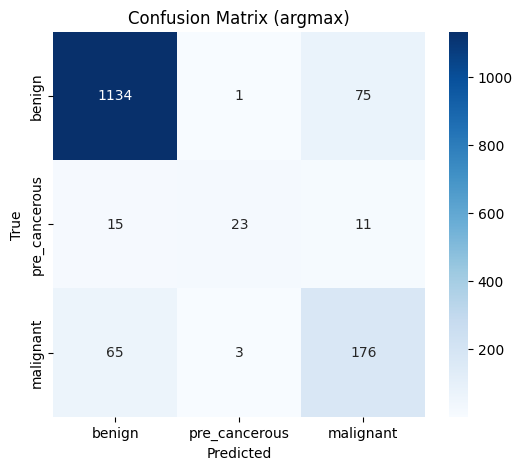

In [12]:
# Cell 10: Evaluate — screener-relevant metrics (sensitivity-first)
def collect_probs(dataset):
    yt, yp = [], []
    for xb, yb in dataset:
        probs = model.predict(xb, verbose=0)
        yt.extend(yb.numpy().tolist())
        yp.append(probs)
    return np.array(yt), np.concatenate(yp, axis=0)


# Keep val arrays around for threshold tuning + temperature scaling in the next cell.
y_val_true, y_val_prob = collect_probs(val_ds)
y_test_true, y_test_prob = collect_probs(test_ds)
y_test_pred = np.argmax(y_test_prob, axis=1)

print("=== Per-class report (argmax baseline) ===")
print(classification_report(y_test_true, y_test_pred, target_names=LABELS, digits=3))

# Per-class sensitivity (recall) and specificity from the confusion matrix.
cm = confusion_matrix(y_test_true, y_test_pred, labels=range(len(LABELS)))
total = cm.sum()
print("=== Per-class sensitivity / specificity ===")
for i, name in enumerate(LABELS):
    tp = cm[i, i]
    fn = cm[i, :].sum() - tp
    fp = cm[:, i].sum() - tp
    tn = total - tp - fn - fp
    sens = tp / (tp + fn) if (tp + fn) else 0.0
    spec = tn / (tn + fp) if (tn + fp) else 0.0
    print(f"  {name:14s} sensitivity={sens:.3f}  specificity={spec:.3f}")

print(f"\nmacro-F1 = {f1_score(y_test_true, y_test_pred, average='macro'):.3f}")

# One-vs-rest ROC-AUC / PR-AUC per class (uses probabilities, threshold-independent).
print("=== ROC-AUC / PR-AUC (one-vs-rest) ===")
for i, name in enumerate(LABELS):
    yt_bin = (y_test_true == i).astype(int)
    if yt_bin.sum() == 0:
        continue
    roc = roc_auc_score(yt_bin, y_test_prob[:, i])
    pr = average_precision_score(yt_bin, y_test_prob[:, i])
    print(f"  {name:14s} ROC-AUC={roc:.3f}  PR-AUC={pr:.3f}")

# Collapsed "cancerous vs not" screening view — the number that matters for the use case.
p_cancer = y_test_prob[:, PRECANCER_IDX] + y_test_prob[:, MALIGNANT_IDX]
cancer_true = np.isin(y_test_true, [PRECANCER_IDX, MALIGNANT_IDX]).astype(int)
cancer_pred = (p_cancer >= 0.5).astype(int)
print("\n=== Screening view: cancerous (pre+mal) vs benign, threshold 0.5 ===")
print(classification_report(cancer_true, cancer_pred, target_names=["benign", "cancerous"], digits=3))
print(f"screening ROC-AUC = {roc_auc_score(cancer_true, p_cancer):.3f}")

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=LABELS, yticklabels=LABELS)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (argmax)")
plt.show()


In [ ]:
# Cell 10b: Calibration (temperature scaling) + sensitivity-first decision threshold
from scipy.optimize import minimize_scalar

MODELS = PROJECT / "models"
MODELS.mkdir(exist_ok=True)

# --- Temperature scaling, fit on the VALIDATION split ---
# softmax(log(p) / T) is a valid temperature reparameterisation, so log(prob) works as a
# logit surrogate without rebuilding the model. Save logits so scripts/fit_temperature.py
# can reproduce the fit headlessly.
val_logits = np.log(np.clip(y_val_prob, 1e-7, 1.0))


def _val_nll(T):
    z = val_logits / T
    z = z - z.max(axis=1, keepdims=True)
    p = np.exp(z)
    p = p / p.sum(axis=1, keepdims=True)
    idx = y_val_true.astype(int)
    return float(-np.mean(np.log(p[np.arange(len(idx)), idx] + 1e-12)))


nll_before = _val_nll(1.0)
res = minimize_scalar(_val_nll, bounds=(0.5, 5.0), method="bounded")
T_opt = float(res.x)
nll_after = _val_nll(T_opt)
with open(MODELS / "temperature.json", "w") as f:
    json.dump(
        {"T": T_opt, "fit_on": "val", "val_nll_before": nll_before, "val_nll_after": nll_after},
        f, indent=2,
    )
print(f"Temperature T={T_opt:.3f}   NLL {nll_before:.4f} -> {nll_after:.4f}")

# --- Sensitivity-first decision threshold on cancer probability (tuned on VALIDATION) ---
TARGET_SENSITIVITY = 0.90
p_cancer_val = y_val_prob[:, PRECANCER_IDX] + y_val_prob[:, MALIGNANT_IDX]
cancer_true_val = np.isin(y_val_true, [PRECANCER_IDX, MALIGNANT_IDX]).astype(int)

grid = np.linspace(0.05, 0.95, 181)
meeting = []
for thr in grid:
    pred = (p_cancer_val >= thr).astype(int)
    sens = recall_score(cancer_true_val, pred, zero_division=0)
    spec = recall_score(1 - cancer_true_val, 1 - pred, zero_division=0)
    if sens >= TARGET_SENSITIVITY:
        meeting.append((float(thr), float(sens), float(spec)))

if meeting:
    # highest threshold that still meets target sensitivity => best specificity at that recall
    thr_opt, sens_opt, spec_opt = max(meeting, key=lambda t: t[0])
else:
    # fall back to the threshold with the highest sensitivity achievable
    thr_opt = 0.5
    pred = (p_cancer_val >= thr_opt).astype(int)
    sens_opt = float(recall_score(cancer_true_val, pred, zero_division=0))
    spec_opt = float(recall_score(1 - cancer_true_val, 1 - pred, zero_division=0))
    print("WARNING: target sensitivity not reachable on val; using 0.5 fallback.")

with open(MODELS / "thresholds.json", "w") as f:
    json.dump(
        {
            "screen_cancer_threshold": thr_opt,
            "target_sensitivity": TARGET_SENSITIVITY,
            "val_sensitivity": sens_opt,
            "val_specificity": spec_opt,
            "labels": LABELS,
            "precancer_idx": PRECANCER_IDX,
            "malignant_idx": MALIGNANT_IDX,
            "decision": "flag cancerous if p(pre_cancerous)+p(malignant) >= screen_cancer_threshold",
        },
        f, indent=2,
    )
print(f"Cancer-screen threshold={thr_opt:.3f}  val sensitivity={sens_opt:.3f} specificity={spec_opt:.3f}")

# Show the screening view re-scored at the tuned threshold on the TEST split.
cancer_pred_test = (p_cancer >= thr_opt).astype(int)
print("\n=== Screening view re-scored at tuned threshold (TEST) ===")
print(classification_report(cancer_true, cancer_pred_test, target_names=["benign", "cancerous"], digits=3))


In [ ]:
# Cell 11: Export .tflite + labels. (The Keras model stays in training/, which git ignores.)
MODELS = PROJECT / "models"
MODELS.mkdir(exist_ok=True)
model.save(PROJECT / "training" / "skin_classifier_full.keras")


def representative_dataset():
    # calib_ds is the finite, non-augmented training set (built in Cell 6).
    for x_batch, _ in calib_ds.take(100):
        yield [x_batch]


# Dynamic-range quantised, float32 in/out: what dermascan/classifier.py expects.
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset
tflite_model = converter.convert()
(MODELS / "skin_classifier.tflite").write_bytes(tflite_model)
(MODELS / "labels.txt").write_text("\n".join(LABELS) + "\n")

print("Saved to", MODELS)
print(f"- skin_classifier.tflite ({len(tflite_model)} bytes)")
print("- labels.txt, thresholds.json, temperature.json")
print("Next: python training/eval.py   (then commit models/ on the branch)")
